**This file deals with the checking of data quality and all the important things we notice in our data**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2.1 Load the merged dataset and replace `-99999` to `NAN`

In [12]:
# import the merged data
df = pd.read_csv('D:/Study/IFRS-9-Complient-Risk-Analysis-modelling/data/merged_dataset.csv')
print(df.shape)

df = df.replace(-99999 , np.nan)

(51336, 87)


In [13]:
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,NaN,0,0,AL,AL,753,P1


### 2.2 Duplicate Analysis

In [15]:
df["PROSPECTID"].duplicated().sum() # There are no duplicated data for a ProspectID
# implies there are no duplicate customers present in our dataset.

np.int64(0)

### 2.3 Missing Value Analysis

In [39]:
total_nulls = df.isnull().sum()
pct_nulls = round(df.isnull().sum()/df.shape[0]*100 , 2)

null_summary = pd.DataFrame({
    "Total Nulls": total_nulls,
    "Percentage (%)": pct_nulls
})

null_summary.sort_values(by = 'Percentage (%)' , ascending=False , inplace=True)
null_summary = null_summary[null_summary['Percentage (%)'] > 0]

print(null_summary)


                              Total Nulls  Percentage (%)
CC_utilization                      47636           92.79
PL_utilization                      44435           86.56
time_since_recent_deliquency        35949           70.03
max_delinquency_level               35949           70.03
time_since_first_deliquency         35949           70.03
max_unsec_exposure_inPct            23178           45.15
max_deliq_6mts                      12890           25.11
max_deliq_12mts                     10832           21.10
tot_enq                              6321           12.31
CC_enq                               6321           12.31
CC_enq_L12m                          6321           12.31
time_since_recent_enq                6321           12.31
PL_enq                               6321           12.31
PL_enq_L6m                           6321           12.31
PL_enq_L12m                          6321           12.31
CC_enq_L6m                           6321           12.31
enq_L6m       

- On looking closely at the missing values, some of the columns look like they have missing values for a reason. Example -> There are `47636` missing values in `CC_utilization` and it is directly linked with `CC_Flag` and similarly other columns too.

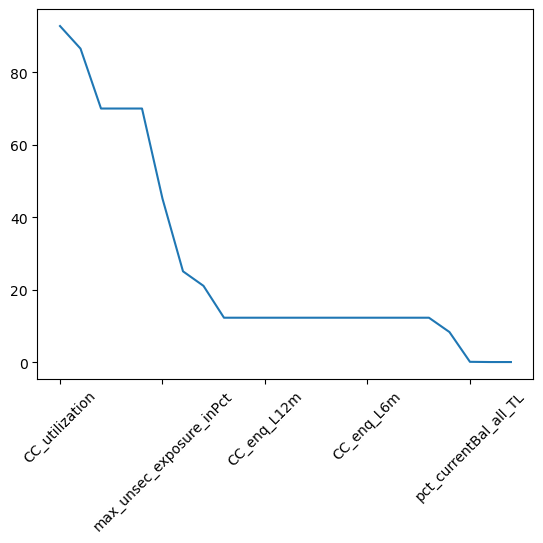

In [38]:
null_summary['Percentage (%)'].plot()
plt.xticks(rotation=45)
plt.show()

### 2.4 Data Type Validation

In [49]:
# Checking the object dtype 
object_type = df.select_dtypes(include=('object')).columns.to_list()
int_type = df.select_dtypes(include=('int')).columns.to_list()
float_type = df.select_dtypes(include=('float')).columns.to_list()

In [51]:
# Checking the 
for i in object_type:
    print(df[i].value_counts())
    print('='*100)
    print('='*100)
    

MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64
GENDER
M    45245
F     6091
Name: count, dtype: int64
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64
